# COMP30850 Assignment — Spring 2025/26

**Deadline: Sunday 8th March 2026**

## Overview

Analysing bike rental data can offer valuable insight into how people move around urban spaces, revealing patterns of everyday travel. This assignment involves applying **network analysis and visualisation** techniques to a Dublin bike rental dataset to identify hub stations, frequent routes between bike stations, and temporal trends.

The assignment should be implemented as a **single Jupyter Notebook** (not a script). Your notebook should be clearly documented, using comments and Markdown cells to explain the code and interpret the results of your analysis.

The data for the assignment is available at: http://mlg.ucd.ie/modules/COMP30850/bike-data.zip

This data contains two separate files:

1. **stations.csv** — Information about individual bike rental stations, one station per row with a unique identifier.
2. **rentals.csv** — List of bike rentals, one row per trip, including the identifiers of the start and end stations.

## AI Use Statement

At the beginning of your notebook, you must include an "AI Use Statement" in a Markdown cell. This is required even if you did not use any generative AI tools. If you do use generative AI, list the tool (and model, if known) and describe how it was used (e.g., understanding data, debugging or generating code). **Penalties will apply if this statement is missing or inaccurate.**

---

First, I pulled all relevant files into a monorepo which I opened in Cursor. This included all of the lab solutions, the assignment doc, overview doc and grading rubric. I then used an instance of Claude Code to generate me the boiler plate of the notebook that I'd be submitting. Instructing it on how to format it, including the details of each task and the rubric at the start of each task. I did this so I can clearly see if the goals are being met.

For each task I followed the same workflow. I asked claudecode what are the relevant labs I should look at to answer the task. Then I went to the labs and asked cursor to explain the lab solutions. I then used this to write the task solutions. 

I also used cursor to generate any matplotlib graphs, where I gave it explicit instructions on what to create. I did this as I can never remember the syntax for matplotlib

I also used cursor on my browser to help rewrite some of my analysises.

In [223]:
# Uncomment and run to install required packages
# !pip install networkx pandas matplotlib seaborn numpy

---

## Task 1 — Static Network Construction


- Task 1: Static Network Construction
- To analyse the station-to-station movement, create an appropriate network representation from the raw data with the following properties:
- Each node represents a unique station, identified by a unique identifier. It should also have attributes containing the station's name and area.
- Each edge indicates one or more trips from an origin station to a different destination station.

---


| Component | Mark |
| --- | --- |
| Data loading and parsing | |
| Construction of an appropriate static network | |
| **Task 1 Total** | **15** |

In [224]:
import networkx as nx
import pandas as pd
from collections import Counter

Data loading and parsing

In [225]:
df_stations = pd.read_csv("../Downloads/bike-data/stations.csv")
df_rentals = pd.read_csv("../Downloads/bike-data/rentals.csv")
print(f"{len(df_stations)} stations")
print(f"{len(df_rentals)} rental records")

110 stations
2198 rental records


In [226]:
df_stations.head()

,station_id,name,capacity,area
0,ST_0001,Smithfield North,42,Northside
1,ST_0002,Parnell Square North,45,Northside
2,ST_0003,Clonmel Street,40,Southside
3,ST_0004,Avondale Road,40,Northside
4,ST_0005,Mount Street Lower,38,Southside


In [227]:
df_rentals.head()

,year,month,day,hour,start_station_id,end_station_id
0,2026,1,27,19,ST_0018,ST_0057
1,2026,1,26,16,ST_0028,ST_0041
2,2026,1,31,7,ST_0013,ST_0060
3,2026,1,28,10,ST_0064,ST_0095
4,2026,1,26,12,ST_0020,ST_0042


Construction of an appropriate static network

In [228]:
# create a directed network and add the nodes from the stations data  # Lab 04
g = nx.DiGraph()
for i, row in df_stations.iterrows():
    g.add_node(row["station_id"], name=row["name"], area=row["area"])

In [230]:
# count the trip frequencies between each pair of stations  (from lab 03)
freqs = Counter()
for i, row in df_rentals.iterrows():
    node1 = row["start_station_id"]
    node2 = row["end_station_id"]
    if node1 == node2:
        continue
    pair = (node1, node2)
    freqs[pair] += 1

# also from lab 03
for pair in freqs:
    g.add_edge(pair[0], pair[1], weight=freqs[pair])

print(f"Network has {g.number_of_nodes()} nodes and {g.number_of_edges()} edges")

Network has 110 nodes and 1187 edges


---

## Task 2 — Static Network Characterisation


- Task 2: Static Network Characterisation
- Apply a range of different methods to characterise the structure and connectivity of the bike-trip network created in Task 1.
- Apply several different centrality measures to identify hub stations in the bike-trip network. Discuss how the centrality scores might be interpreted in each case.
- Identify any stations with significant positive net flow (more arrivals than departures) and significant negative net flow (more departures than arrivals).

---


| Component | Mark |
| --- | --- |
| Characterisation of the static network | |
| Centrality analysis of the static network | |
| Identify any stations with significant positive net flow and significant negative net flow | |
| **Task 2 Total** | **30** |

In [231]:
import matplotlib.pyplot as plt
%matplotlib inline

Apply a range of different methods to characterise the **structure and connectivity** of the bike-trip network created in Task 1.

In [232]:
# how many nodes and edges are in the network?  # Lab 03
print(f"Network has {g.number_of_nodes()} nodes and {g.number_of_edges()} edges")

Network has 110 nodes and 1187 edges


In [233]:
# what level of density in the network?  # Lab 03
nx.density(g)

0.09899916597164303

In [234]:
# how many strongly connected components?  # Lab 03
nx.number_strongly_connected_components(g)

7

In [235]:
# how many weakly connected components?  # Lab 03
nx.number_weakly_connected_components(g)

1

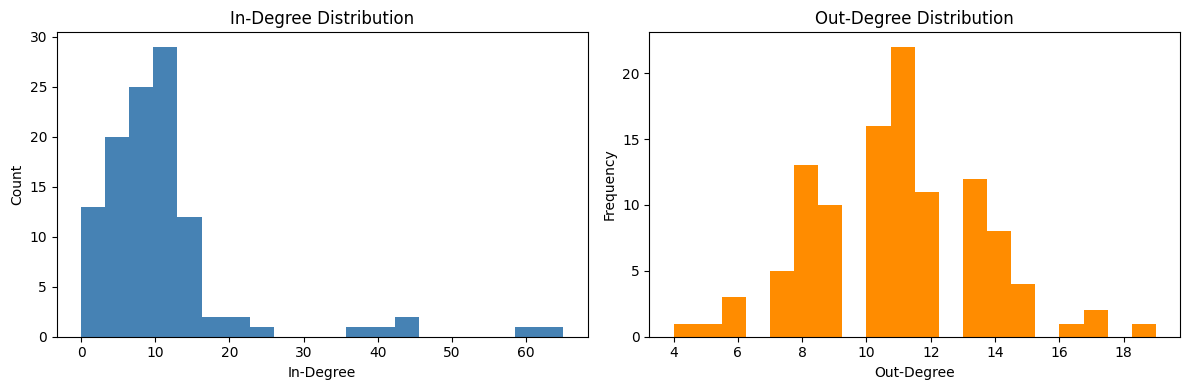

In [236]:
# create pandas series for in-degree and out-degree scores  # Lab 03
s_in = pd.Series(dict(g.in_degree()))
s_out = pd.Series(dict(g.out_degree()))

# plot degree distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
s_in.plot.hist(bins=20, ax=axes[0], color="steelblue")
axes[0].set_title("In-Degree Distribution")
axes[0].set_xlabel("In-Degree")
axes[0].set_ylabel("Count")

s_out.plot.hist(bins=20, ax=axes[1], color="darkorange")
axes[1].set_title("Out-Degree Distribution")
axes[1].set_xlabel("Out-Degree")
plt.tight_layout()
plt.show()

The network has a density of around 10% which is relatively high for a real-world network, meaning stations are well connected to each other. There is only 1 weakly connected component so every station can reach every other station via some path. The 7 strongly connected components suggest a small number of stations that trips only flow into or out of but not both ways. The degree distributions show most stations have low to moderate connectivity with a few high-degree hubs pulling away from the rest.

Apply several different **centrality measures** to identify hub stations in the bike-trip network. Discuss how the centrality scores might be interpreted in each case.

In [237]:
# in-degree: stations that receive trips from the most distinct origins  # Lab 03
s_in = pd.Series(dict(g.in_degree()))
s_in.sort_values(ascending=False).head(10)

ST_0095    65
ST_0068    59
ST_0002    45
ST_0066    45
ST_0001    41
ST_0102    37
ST_0073    23
ST_0014    22
ST_0053    20
ST_0090    17
dtype: int64

In-degree identifies the most popular destination stations. A high score means many distinct stations send trips here, so it's a common endpoint regardless of where a journey starts.

In [238]:
# out-degree: stations that send trips to the most distinct destinations  # Lab 03
s_out = pd.Series(dict(g.out_degree()))
s_out.sort_values(ascending=False).head(10)

ST_0066    19
ST_0009    17
ST_0068    17
ST_0032    16
ST_0027    15
ST_0002    15
ST_0085    15
ST_0095    15
ST_0087    14
ST_0080    14
dtype: int64

Out-degree identifies the most popular departure stations. A high score means trips from here spread across many different destinations, so it's a common starting point.

In [239]:
# weighted in-degree: total number of arrivals  # Lab 03
s_win = pd.Series(dict(g.in_degree(weight="weight")))
s_win.sort_values(ascending=False).head(10)

ST_0095    268
ST_0068    201
ST_0002    134
ST_0066    127
ST_0001     96
ST_0102     64
ST_0039     45
ST_0073     34
ST_0014     31
ST_0053     24
dtype: int64

Weighted in-degree captures total arrival volume rather than just the number of distinct origins. A station can have moderate in-degree but very high weighted in-degree if the same routes are used repeatedly.

In [240]:
# weighted out-degree: total number of departures  # Lab 03
s_wout = pd.Series(dict(g.out_degree(weight="weight")))
s_wout.sort_values(ascending=False).head(10)

ST_0095    41
ST_0002    37
ST_0068    33
ST_0041    33
ST_0014    32
ST_0026    30
ST_0066    30
ST_0090    30
ST_0009    29
ST_0102    29
dtype: int64

Weighted out-degree captures total departure volume. It shows which stations are the busiest in terms of trips generated, not just how many destinations they connect to.

In [241]:
# betweenness centrality: key connector stations in the network  # Lab 03, Lab 08
s_bet = pd.Series(nx.betweenness_centrality(g))
s_bet.sort_values(ascending=False).head(10)

ST_0066    0.285891
ST_0039    0.133990
ST_0068    0.104559
ST_0095    0.096488
ST_0013    0.053196
ST_0103    0.049143
ST_0042    0.037437
ST_0028    0.037339
ST_0018    0.030484
ST_0033    0.025947
dtype: float64

Betweenness centrality identifies stations that sit on the most shortest paths between other stations. A high score means the station is a key connector. Removing it would most disrupt flow across the network, even if it is not the busiest station by trip count.

Identify any stations with significant **positive net flow** (more arrivals than departures) and significant **negative net flow** (more departures than arrivals).

In [242]:
# find the most frequent origin and destination stations, based on weighted degrees  # Lab 03
s_win = pd.Series(dict(g.in_degree(weight="weight")))
s_wout = pd.Series(dict(g.out_degree(weight="weight")))

# net flow = arrivals - departures
s_net_flow = s_win - s_wout

# add station names for readability
station_names = {row["station_id"]: row["name"] for _, row in df_stations.iterrows()}

In [243]:
# significant positive net flow: more arrivals than departures (bike accumulation)
top_pos = s_net_flow.sort_values(ascending=False).head(10)
pd.DataFrame({"station": top_pos.index.map(station_names), "net_flow": top_pos.values}, index=top_pos.index)

,station,net_flow
ST_0095,Princes Street / O'Connell Street,227
ST_0068,St. Stephen'S Green South,168
ST_0002,Parnell Square North,97
ST_0066,Merrion Square East,97
ST_0001,Smithfield North,76
ST_0102,Jervis Street,35
ST_0039,Kilmainham Gaol,27
ST_0073,St. Stephen'S Green East,15
ST_0081,Blessington Street,14
ST_0030,Merrion Square South,9


In [244]:
# significant negative net flow: more departures than arrivals (bike depletion)
top_neg = s_net_flow.sort_values(ascending=True).head(10)
pd.DataFrame({"station": top_neg.index.map(station_names), "net_flow": top_neg.values}, index=top_neg.index)

,station,net_flow
ST_0009,York Street East,-24
ST_0012,Portobello Road,-19
ST_0046,High Street,-19
ST_0088,Dame Street,-19
ST_0110,Blackhall Place,-19
ST_0076,Georges Lane,-18
ST_0077,Phibsborough Road,-18
ST_0004,Avondale Road,-17
ST_0059,Georges Quay,-17
ST_0072,Grangegorman Lower (North),-17


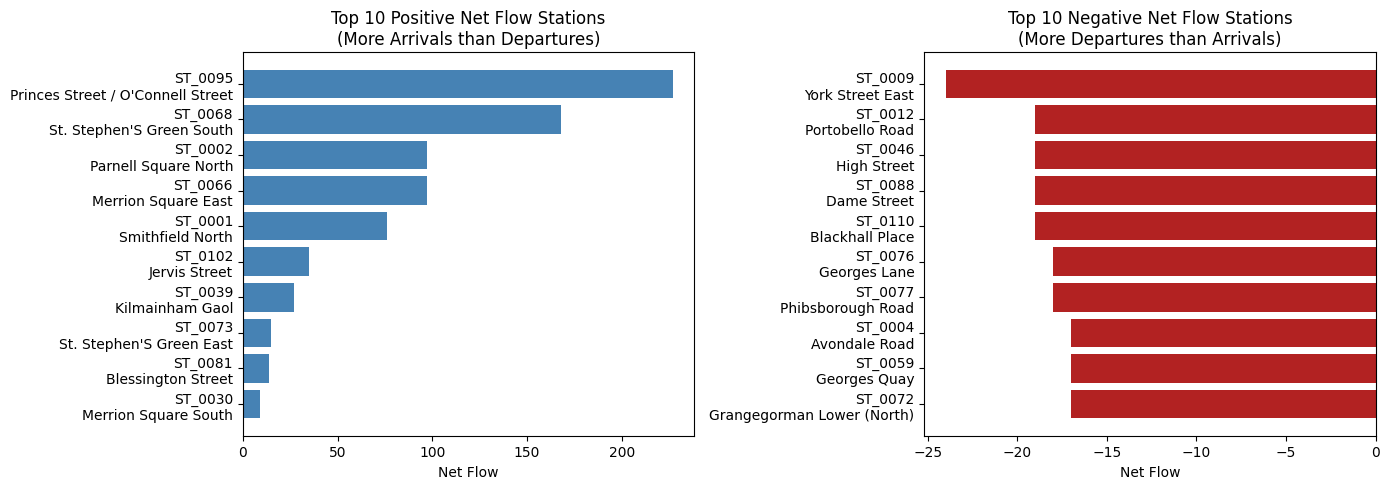

In [245]:
# bar chart comparing positive and negative net flow stations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pos_labels = [f"{sid}\n{station_names.get(sid,'')}" for sid in top_pos.index]
axes[0].barh(pos_labels[::-1], top_pos.values[::-1], color="steelblue")
axes[0].set_title("Top 10 Positive Net Flow Stations\n(More Arrivals than Departures)")
axes[0].set_xlabel("Net Flow")

neg_labels = [f"{sid}\n{station_names.get(sid,'')}" for sid in top_neg.index]
axes[1].barh(neg_labels[::-1], top_neg.values[::-1], color="firebrick")
axes[1].set_title("Top 10 Negative Net Flow Stations\n(More Departures than Arrivals)")
axes[1].set_xlabel("Net Flow")

plt.tight_layout()
plt.show()

---

## Task 3 — Static Network Visualisation


- Task 3: Static Network Visualisation
- Extract a subgraph from the bike-trip network created in Task 1 containing only the stations located in the 'Northside' area of Dublin. Export this subgraph as a GEXF file.
- Load the GEXF file in Gephi. Use Gephi's layout functionality to create several useful visualisations of the subgraph. Your visualisations should highlight different aspects such as the network's overall connectivity structure. Export the final visualisations as PNG files.

---

| Component | Mark |
| --- | --- |
| Creation and export of the required subgraph | |
| Visualisations of the subgraph using Gephi | |
| **Task 3 Total** | **20** |

Creation and export of the required subgraph

In [246]:
# find the nodes representing Northside stations  # Lab 05
northside_nodes = [n for n, attr in g.nodes(data=True) if attr["area"] == "Northside"]
# create a subgraph with the filtered nodes  # Lab 05
g_northside = g.subgraph(northside_nodes)
print(f"Northside subgraph: {g_northside.number_of_nodes()} nodes and {g_northside.number_of_edges()} edges")

Northside subgraph: 43 nodes and 429 edges


In [247]:
# save the northside subgraph as a GEXF file  # Lab 04
nx.write_gexf(g_northside, "northside.gexf")

*See exported PNG files in the submission ZIP.*

---

## Task 4 — Dynamic Network Analysis


- Task 4: Dynamic Network Analysis
- Using the dates associated with each trip, construct a set of daily time networks representing station-to-station movement on each day.
- Apply various methods to characterise the global structure and connectivity of the daily networks. Compare these network-level metrics across different days and discuss any temporal patterns you observe.
- By analysing station-level activity over time, identify stations where capacity should be increased by the bike rental operator.

---

| Component | Mark |
| --- | --- |
| Creation of time window networks | |
| Analysis of the time window networks using global measures | |
| Identify stations where capacity should be increased | |
| **Task 4 Total** | **25** |

Using the dates associated with each trip, construct a set of **daily time networks** representing station-to-station movement on each day.

In [248]:
# group rental records into separate DataFrames, one per day  # Lab 09
df_rentals["date"] = pd.to_datetime(df_rentals[["year", "month", "day"]])
daily_frames = dict(tuple(df_rentals.groupby("date")))
print(f"Found {len(daily_frames)} unique days")

Found 7 unique days


In [249]:
# construct a directed network for each day  # Lab 09
daily_networks = {}
for date, wf in sorted(daily_frames.items()):
    dg = nx.from_pandas_edgelist(wf, "start_station_id", "end_station_id", create_using=nx.DiGraph())
    daily_networks[date] = dg
    print(f"{date.date()}: {dg.number_of_nodes()} nodes, {dg.number_of_edges()} edges")

2026-01-26: 108 nodes, 291 edges
2026-01-27: 107 nodes, 286 edges
2026-01-28: 108 nodes, 312 edges
2026-01-29: 110 nodes, 306 edges
2026-01-30: 108 nodes, 309 edges
2026-01-31: 107 nodes, 234 edges
2026-02-01: 99 nodes, 190 edges


Apply various methods to characterise the **global structure and connectivity** of the daily networks. Compare these network-level metrics across different days and discuss any temporal patterns you observe.

In [250]:
# define a convenience function for plotting a time series  # Lab 09
def gen_ts_plot(values, measure_name, color):
    s_values = pd.Series(values)
    ax = s_values.plot(figsize=(10, 5), style=".-", ms=12, fontsize=12, color=color, linewidth=2, zorder=3)
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel(measure_name, fontsize=12)
    ax.set_title(f"{measure_name} over time", fontsize=12)
    ax.xaxis.grid()
    plt.show()

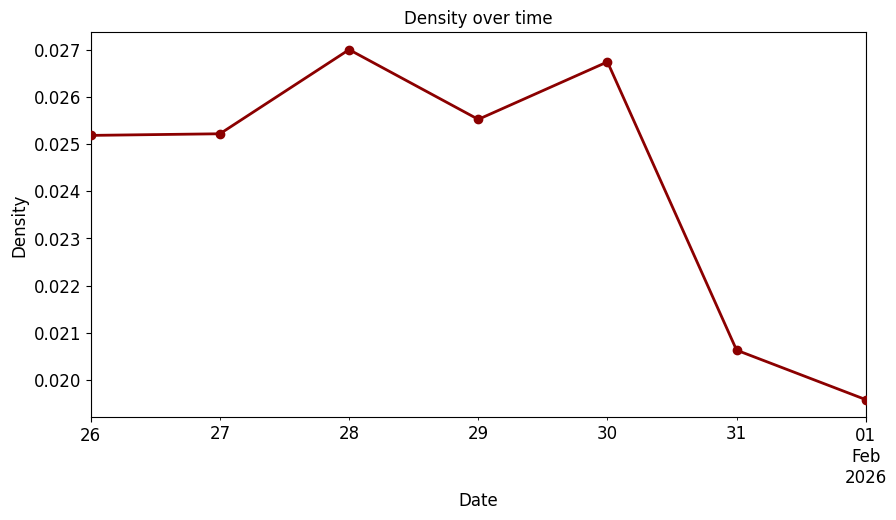

In [251]:
# calculate the density for each daily network  # Lab 09
values = {}
for date, dg in daily_networks.items():
    values[date] = nx.density(dg)
gen_ts_plot(values, "Density", "darkred")

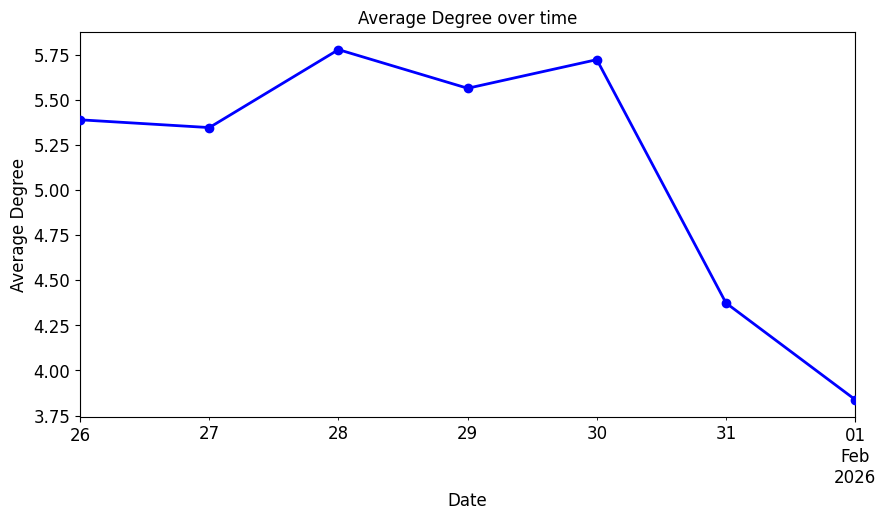

In [252]:
# calculate the average degree for each daily network  # Lab 09
values = {}
for date, dg in daily_networks.items():
    degrees = dict(dg.degree()).values()
    values[date] = sum(degrees) / len(degrees)
gen_ts_plot(values, "Average Degree", "blue")

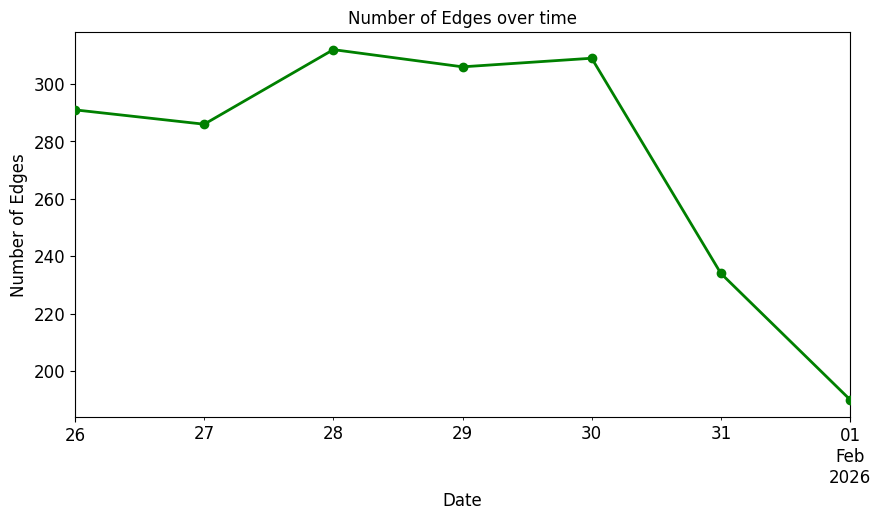

In [253]:
# calculate the number of active edges for each daily network  # Lab 09
values = {}
for date, dg in daily_networks.items():
    values[date] = dg.number_of_edges()
gen_ts_plot(values, "Number of Edges", "green")

There is a clear weekday vs weekend pattern. Monday to Friday (Jan 26-30) the network is consistently more active, with edge counts between 291 and 312 and average degree around 5.3 to 5.8. Wednesday Jan 28 was the busiest day. 

Activity drops noticeably on Saturday (234 edges, avg degree 4.4) and hits its lowest point on Sunday (190 edges, avg degree 3.8). 

Density follows the same pattern. This makes sense as weekday usage is likely driven by commuting, while weekend trips are more sparse and spread across fewer station pairs.

By analysing station-level activity over time, identify stations where **capacity should be increased** by the bike rental operator.

In [254]:
# calculate average daily arrivals and departures per station  # Lab 09
avg_arrivals = {}
avg_departures = {}
for node in g.nodes():
    arrivals = [dg.in_degree(node) if node in dg else 0 for dg in daily_networks.values()]
    departures = [dg.out_degree(node) if node in dg else 0 for dg in daily_networks.values()]
    avg_arrivals[node] = sum(arrivals) / len(daily_networks)
    avg_departures[node] = sum(departures) / len(daily_networks)

# build a DataFrame comparing activity to station capacity
df_activity = df_stations.set_index("station_id")[["name", "capacity"]].copy()
df_activity["avg_daily_arrivals"] = pd.Series(avg_arrivals)
df_activity["avg_daily_departures"] = pd.Series(avg_departures)
df_activity["avg_daily_trips"] = df_activity["avg_daily_arrivals"] + df_activity["avg_daily_departures"]
df_activity["trips_per_capacity"] = df_activity["avg_daily_trips"] / df_activity["capacity"]
df_activity.sort_values("trips_per_capacity", ascending=False).head(10)

,name,capacity,avg_daily_arrivals,avg_daily_departures,avg_daily_trips,trips_per_capacity
station_id,,,,,,
ST_0068,St. Stephen'S Green South,41,22.857143,4.428571,27.285714,0.665505
ST_0095,Princes Street / O'Connell Street,48,26.571429,4.857143,31.428571,0.654762
ST_0066,Merrion Square East,40,14.142857,3.857143,18.000000,0.450000
ST_0002,Parnell Square North,45,15.714286,4.285714,20.000000,0.444444
ST_0001,Smithfield North,42,12.000000,2.714286,14.714286,0.350340
ST_0102,Jervis Street,46,8.428571,3.571429,12.000000,0.260870
ST_0039,Kilmainham Gaol,30,5.285714,2.428571,7.714286,0.257143
ST_0073,St. Stephen'S Green East,41,4.857143,2.571429,7.428571,0.181185
ST_0014,Parnell Street,46,4.571429,3.714286,8.285714,0.180124


The stations ranked highest by trips per capacity are the ones under the most pressure relative to their dock count. **St. Stephen's Green South** and **Princes Street / O'Connell Street** are the clearest candidates for a capacity increase, both seeing over 0.65 trips per dock per day on average. Both are high-footfall city centre locations which explains the demand. Parnell Square North and Merrion Square East are also worth watching.